# Cesium Lead Bromide Nep Tdep

### Anharmonic Lattice Dynamics (ALD) for $\ce{c-CsPbBr3}$ with [NEP](https://pubs.acs.org/doi/full/10.1021/acs.jpcc.3c01542)

#### Import Necessary Packages

In [1]:
from ase.io import read
from pylab import *
import warnings
warnings.filterwarnings("ignore")

#### Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequency or mean-free path

       input:
       observables: (ndarray) either phonon frequency or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       ouput:
       observeables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

#### Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

#### Plot Phonon Spectra (Dispersion) and Density of State (DOS) at 360 and 500K

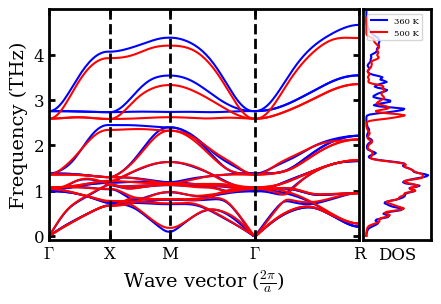

In [4]:
data_folder_360K = '360K/kaldo_runs/'
data_folder_500K = '500K/kaldo_runs/'

# Derive symbols for high symmetry directions in Brillouin zone
dispersion_360K = np.loadtxt(data_folder_360K  + 'plots/12_12_12/dispersion')
point_names_360K = np.loadtxt(data_folder_360K  + 'plots/12_12_12/point_names', dtype=str)

dispersion_500K = np.loadtxt(data_folder_500K  + 'plots/12_12_12/dispersion')
point_names_500K = np.loadtxt(data_folder_500K  + 'plots/12_12_12/point_names', dtype=str)

point_names_list_360K = []
point_names_list_500K = []
for point_name in point_names_360K:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list_360K.append(point_name)

for point_name in point_names_500K:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list_500K.append(point_name)

# Load in the "tick-mark" values for these symbols
q_360K = np.loadtxt(data_folder_360K  + 'plots/12_12_12/q')
Q_360K = np.loadtxt(data_folder_360K  + 'plots/12_12_12/Q_val')

q_500K = np.loadtxt(data_folder_500K  + 'plots/12_12_12/q')
Q_500K = np.loadtxt(data_folder_500K  + 'plots/12_12_12/Q_val')

# Load in grid and dos individually
dos_360K= np.load(data_folder_360K + 'plots/12_12_12/dos.npy')
dos_500K= np.load(data_folder_500K + 'plots/12_12_12/dos.npy')

# Plot dispersion
fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q_360K[0], dispersion_360K[0, 0], 'b-', ms=1)
plot(q_360K, dispersion_360K, 'b-', ms=1)
plot(q_500K[0], dispersion_500K[0, 0], 'r-', ms=1)
plot(q_500K, dispersion_500K, 'r-', ms=1)
for i in range(1, 4):
    axvline(x=Q_360K[i], ymin=0, ymax=2, ls='--',  lw=2, c="k")
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 5, 1))
xticks(Q_360K, point_names_list_360K)
ylim([-0.1, 5])
xlim([Q_360K[0], Q_360K[4]])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])

# Plot per projection
for d in np.expand_dims(dos_360K[1],0):
    dosax.plot(d, dos_360K[0],c='b', label='360 K')
for d in np.expand_dims(dos_500K[1],0):
    dosax.plot(d, dos_500K[0],c='r', label='500 K')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
legend(fontsize=6, loc=2)
ylim([-0.1, 5])
show()

### Plot Heat Capacity, Group Velocities and Phase Space

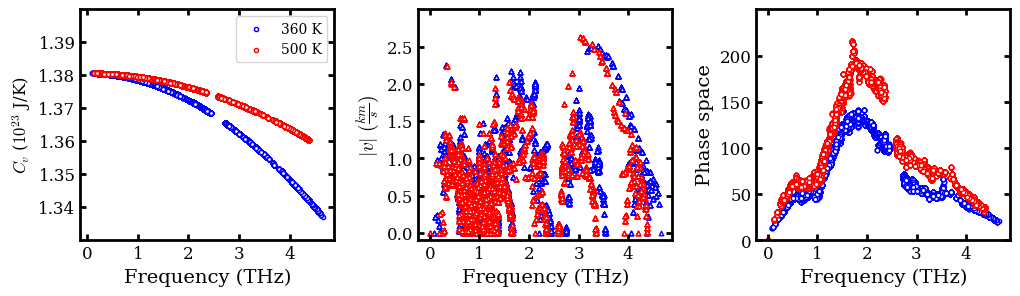

In [5]:
# Load in group velocity, heat_capacity (cv) and frequency data
frequency_360K =  np.load(
    data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/frequency.npy',
    allow_pickle=True)

cv_360K =  np.load(
    data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/360/quantum/heat_capacity.npy',
    allow_pickle=True)

frequency_500K =  np.load(
    data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/frequency.npy',
    allow_pickle=True)

cv_500K =  np.load(
    data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/500/quantum/heat_capacity.npy',
    allow_pickle=True)



group_velocity_360K = np.load(
    data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/velocity.npy')

phase_space_360K = np.load(data_folder_360K +
 'ALD_CsPbBr3_NEP/12_12_12/360/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

group_velocity_500K = np.load(
    data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/velocity.npy')

phase_space_500K = np.load(data_folder_500K +
 'ALD_CsPbBr3_NEP/12_12_12/500/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

# Compute norm of group velocity
# Convert the unit from angstrom / picosecond to kilometer/ second
group_velcotiy_norm_360K = np.linalg.norm(
    group_velocity_360K.reshape(-1, 3), axis=1) / 10.0

group_velcotiy_norm_500K = np.linalg.norm(
    group_velocity_500K.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C')[3:], 1e23*cv_360K.flatten(order='C')[3:], 
        facecolor='w', edgecolor='b', s=10, marker='8', label='360 K')
scatter(frequency_500K.flatten(order='C')[3:], 1e23*cv_500K.flatten(order='C')[3:], 
        facecolor='w', edgecolor='r', s=10, marker='8', label='500 K')
ylabel (r"$C_{v}$ ($10^{23}$ J/K)")
xlabel('Frequency (THz)', fontsize=14)
ylim(1.33, 1.40)
gca().set_yticks(np.arange(1.34, 1.40, 0.01))
gca().set_xticks(np.arange(0, 5, 1))
legend(fontsize=10)
subplot(1 ,3, 2)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C'),
        group_velcotiy_norm_360K, facecolor='w', edgecolor='b', s=10, marker='^')
scatter(frequency_500K.flatten(order='C'),
        group_velcotiy_norm_500K, facecolor='w', edgecolor='r', s=10, marker='^')
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$|v| \ (\frac{km}{s})$', fontsize=14)
gca().set_xticks(np.arange(0, 5, 1))
gca().set_yticks(np.arange(0, 3.0, 0.5))
ylim([-0.1, 3])

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C'),
        phase_space_360K, facecolor='w', edgecolor='b', s=10, marker='o')
scatter(frequency_500K.flatten(order='C'),
        phase_space_500K, facecolor='w', edgecolor='r', s=10, marker='o')
xlabel('Frequency (THz)', fontsize=14)
ylabel('Phase space', fontsize=14)
gca().set_xticks(np.arange(0, 5, 1))
gca().set_yticks(np.arange(0, 250, 50))
ylim([0, 250])
subplots_adjust(wspace=0.33)
show()

### Plot Phonon Lifetime ($\tau$), Scattering Rate ($\Gamma$) $\&$ MFP ($\lambda$)
- Note that $\Gamma$ and $\tau$ are computed only with the relaxation time approximation (RTA).

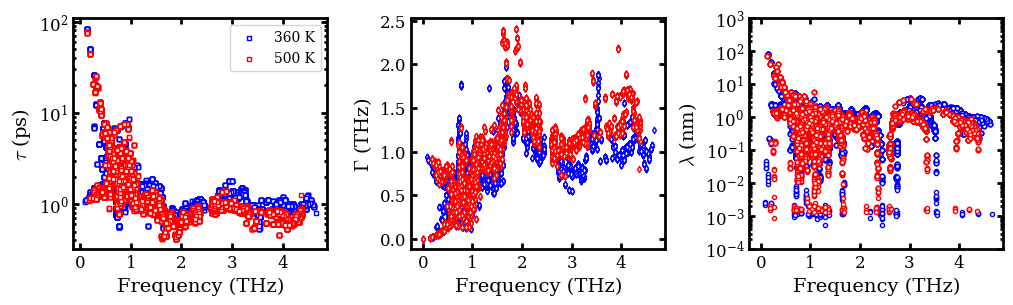

In [6]:
# Load in scattering rate
scattering_rate_360K = np.load(
     data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/360/quantum/bandwidth.npy', allow_pickle=True)
scattering_rate_500K = np.load(
     data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/500/quantum/bandwidth.npy', allow_pickle=True)

# Derive lifetime, which is inverse of scattering rate
life_time_360K = scattering_rate_360K ** (-1)
life_time_500K = scattering_rate_500K ** (-1)

# Denote lists to intake mean free path in each direction
mean_free_path_360K = []
mean_free_path_500K = []

for i in range(3):
    mean_free_path_360K.append(np.loadtxt(
    data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/inverse/360/quantum/mean_free_path_' +
    str(i) + '.dat'))

    mean_free_path_500K.append(np.loadtxt(
    data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/inverse/500/quantum/mean_free_path_' +
    str(i) + '.dat'))
    
# Convert list to numpy array and compute norm for mean free path
# Convert the unit from angstrom  to nanometer
mean_free_path_360K = np.array(mean_free_path_360K).T
mean_free_path_norm_360K = np.linalg.norm(
    mean_free_path_360K.reshape(-1, 3), axis=1) / 10.0

mean_free_path_500K = np.array(mean_free_path_500K).T
mean_free_path_norm_500K = np.linalg.norm(
    mean_free_path_500K.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C'),
        life_time_360K, facecolor='w', edgecolor='b', s=10, marker='s', label='360 K')
scatter(frequency_500K.flatten(order='C'),
        life_time_500K, facecolor='w', edgecolor='r', s=10, marker='s', label='500 K')
gca().set_xticks(np.arange(0, 5, 1))
yscale('log')
ylabel(r'$\tau$ (ps)', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(fontsize=10)

subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C'),
        scattering_rate_360K, facecolor='w', edgecolor='b', s=10, marker='d')
scatter(frequency_500K.flatten(order='C'),
        scattering_rate_500K, facecolor='w', edgecolor='r', s=10, marker='d')
gca().set_xticks(np.arange(0, 5, 1))
ylabel(r'$\Gamma$ (THz)', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 3)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C'),
        mean_free_path_norm_360K, facecolor='w', edgecolor='b', s=10, marker='8')
scatter(frequency_500K.flatten(order='C'),
        mean_free_path_norm_500K, facecolor='w', edgecolor='r', s=10, marker='8')
gca().set_xticks(np.arange(0, 5, 1))
ylabel(r'$\lambda$ (nm)', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-4, 1e3])
subplots_adjust(wspace=0.33)
show()

#### Compute $\kappa_{full, QHGK}$ with Intraband Contributions

In [7]:
# Denote zeros to intake kappa tensor
kappa_tensor_RTA_360K  = np.zeros([mean_free_path_360K .shape[0], 3, 3])
kappa_tensor_Inv_360K  = np.zeros([mean_free_path_360K .shape[0], 3, 3])
kappa_tensor_QHGK_360K  = np.zeros([mean_free_path_360K .shape[0], 3, 3])

kappa_tensor_RTA_500K  = np.zeros([mean_free_path_500K .shape[0], 3, 3])
kappa_tensor_Inv_500K  = np.zeros([mean_free_path_500K .shape[0], 3, 3])
kappa_tensor_QHGK_500K  = np.zeros([mean_free_path_500K .shape[0], 3, 3])

for i in range(3):
    for j in range(3):
        kappa_tensor_RTA_360K [:, i, j] = np.loadtxt(data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/rta/360/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_QHGK_360K [:, i, j] = np.loadtxt(data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/qhgk/360/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_Inv_360K [:, i, j] = np.loadtxt(data_folder_360K + 'ALD_CsPbBr3_NEP/12_12_12/inverse/360/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')

        kappa_tensor_RTA_500K [:, i, j] = np.loadtxt(data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/rta/500/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_QHGK_500K [:, i, j] = np.loadtxt(data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/qhgk/500/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_Inv_500K [:, i, j] = np.loadtxt(data_folder_500K + 'ALD_CsPbBr3_NEP/12_12_12/inverse/500/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
    
    
# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix_RTA_360K =  kappa_tensor_RTA_360K.sum(axis=0)
print("RTA thermal conductivity at 360 K: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_RTA_360K)))
print("RTA kappa matrix at 360 K: ")
print(kappa_matrix_RTA_360K )
print('\n')

kappa_matrix_QHGK_360K =  kappa_tensor_QHGK_360K.sum(axis=0)
print("QHGK thermal conductivity at 360 K: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_QHGK_360K)))
print("QHGK kappa matrix at 360 K: ")
print(kappa_matrix_QHGK_360K )
print('\n')

kappa_matrix_Inv_360K =  kappa_tensor_Inv_360K.sum(axis=0)
kappa_matrix_full_QHGK_360K = (kappa_matrix_QHGK_360K - kappa_matrix_RTA_360K) + kappa_matrix_Inv_360K

print("Full QHGK thermal conductivity at 360 K: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_full_QHGK_360K)))
print("Full QHGK kappa matrix at 360 K: ")
print(kappa_matrix_full_QHGK_360K)
print('\n')


# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix_RTA_500K =  kappa_tensor_RTA_500K.sum(axis=0)
print("RTA thermal conductivity at 500 K: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_RTA_500K)))
print("RTA kappa matrix at 500 K: ")
print(kappa_matrix_RTA_500K )
print('\n')

kappa_matrix_QHGK_500K =  kappa_tensor_QHGK_500K.sum(axis=0)
print("QHGK thermal conductivity at 500 K: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_QHGK_500K)))
print("QHGK kappa matrix at 500 K: ")
print(kappa_matrix_QHGK_500K )
print('\n')

kappa_matrix_Inv_500K =  kappa_tensor_Inv_500K.sum(axis=0)
kappa_matrix_full_QHGK_500K = (kappa_matrix_QHGK_500K - kappa_matrix_RTA_500K) + kappa_matrix_Inv_500K

print("Full QHGK thermal conductivity at 500 K: %.3f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_full_QHGK_500K)))
print("Full QHGK kappa matrix at 500 K: ")
print(kappa_matrix_full_QHGK_500K)


RTA thermal conductivity at 360 K: 0.356 W m^-1 K^-1

RTA kappa matrix at 360 K: 
[[3.56854913e-01 4.87447086e-05 6.16967228e-05]
 [4.87447086e-05 3.55694266e-01 8.79436238e-05]
 [6.16967228e-05 8.79436238e-05 3.56004299e-01]]


QHGK thermal conductivity at 360 K: 0.452 W m^-1 K^-1

QHGK kappa matrix at 360 K: 
[[ 4.52570379e-01 -2.09144568e-04 -2.14926899e-05]
 [-2.09144568e-04  4.52450318e-01 -6.06310217e-05]
 [-2.14926899e-05 -6.06310217e-05  4.52399549e-01]]


Full QHGK thermal conductivity at 360 K: 0.480 W m^-1 K^-1

Full QHGK kappa matrix at 360 K: 
[[ 4.79874779e-01 -2.11513076e-04 -2.17357173e-05]
 [-2.13159634e-04  4.79794449e-01 -4.87985140e-05]
 [-2.32524035e-05 -4.82131606e-05  4.79698815e-01]]


RTA thermal conductivity at 500 K: 0.320 W m^-1 K^-1

RTA kappa matrix at 500 K: 
[[3.20495441e-01 3.55328838e-06 9.62991139e-06]
 [3.55328838e-06 3.18653824e-01 4.68041501e-05]
 [9.62991139e-06 4.68041501e-05 3.19471435e-01]]


QHGK thermal conductivity at 500 K: 0.406 W m^-1 K^-

#### Plot per mode and cumulative $\kappa$

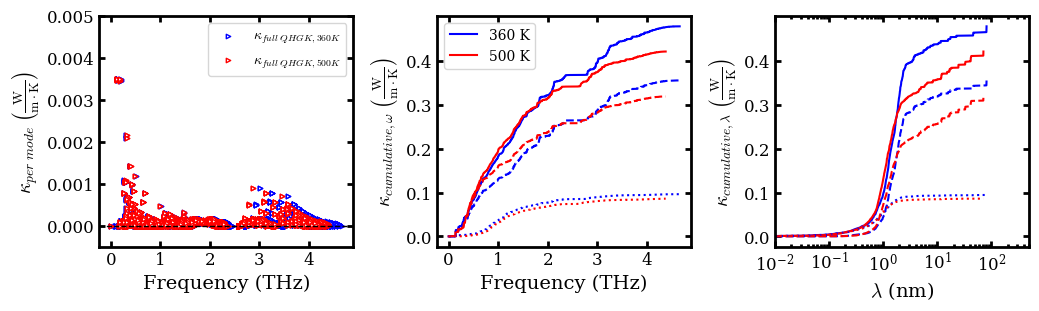

In [8]:
# Compute kappa in per mode and cumulative representations
kappa_tensor_full_QHGK_360K = (kappa_tensor_QHGK_360K - kappa_tensor_RTA_360K) + kappa_tensor_Inv_360K
kappa_per_mode_full_QHGK_360K = kappa_tensor_full_QHGK_360K.sum(axis=-1).sum(axis=1)

# Computation of intra band contributions for cumulative kappa w.r.t frequency at 360K
freq_sorted_full_QHGK_360K, kappa_cum_wrt_freq_full_QHGK_360K = cumulative_cond_cal(
    frequency_360K.flatten(order='C'), kappa_tensor_full_QHGK_360K)

freq_sorted_QHGK_360K, kappa_cum_wrt_freq_QHGK_360K = cumulative_cond_cal(
    frequency_360K.flatten(order='C'), kappa_tensor_QHGK_360K)

freq_sorted_RTA_360K, kappa_cum_wrt_freq_RTA_360K = cumulative_cond_cal(
    frequency_360K.flatten(order='C'), kappa_tensor_RTA_360K)


# Computation of intra band contributions for cumulative kappa w.r.t mean free path (lambda) at 360K
lambda_sorted_full_QHGK_360K, kappa_cum_wrt_lambda_full_QHGK_360K = cumulative_cond_cal(
    mean_free_path_norm_360K, kappa_tensor_full_QHGK_360K)

lambda_sorted_QHGK_360K, kappa_cum_wrt_lambda_QHGK_360K = cumulative_cond_cal(
     mean_free_path_norm_360K, kappa_tensor_QHGK_360K)

lambda_sorted_RTA_360K, kappa_cum_wrt_lambda_RTA_360K = cumulative_cond_cal(
     mean_free_path_norm_360K, kappa_tensor_RTA_360K)


# Computation of intra band contributions for cumulative kappa w.r.t frequency at 500K
kappa_tensor_full_QHGK_500K = (kappa_tensor_QHGK_500K - kappa_tensor_RTA_500K) + kappa_tensor_Inv_500K
kappa_per_mode_full_QHGK_500K = kappa_tensor_full_QHGK_500K.sum(axis=-1).sum(axis=1)

freq_sorted_full_QHGK_500K, kappa_cum_wrt_freq_full_QHGK_500K = cumulative_cond_cal(
    frequency_500K.flatten(order='C'), kappa_tensor_full_QHGK_500K)

freq_sorted_RTA_500K, kappa_cum_wrt_freq_RTA_500K = cumulative_cond_cal(
    frequency_500K.flatten(order='C'), kappa_tensor_RTA_500K)

freq_sorted_QHGK_500K, kappa_cum_wrt_freq_QHGK_500K = cumulative_cond_cal(
    frequency_500K.flatten(order='C'), kappa_tensor_QHGK_500K)

# Computation of intra band contributions for cumulative kappa w.r.t mean free path (lambda) at 500K
lambda_sorted_full_QHGK_500K, kappa_cum_wrt_lambda_full_QHGK_500K = cumulative_cond_cal(
    mean_free_path_norm_500K, kappa_tensor_full_QHGK_500K)

lambda_sorted_QHGK_500K, kappa_cum_wrt_lambda_QHGK_500K = cumulative_cond_cal(
     mean_free_path_norm_500K, kappa_tensor_QHGK_500K)

lambda_sorted_RTA_500K, kappa_cum_wrt_lambda_RTA_500K = cumulative_cond_cal(
     mean_free_path_norm_500K, kappa_tensor_RTA_500K)

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency_360K.flatten(order='C'),
        kappa_per_mode_full_QHGK_360K, facecolor='w', edgecolor='b', s=10, marker='>', label='$\kappa_{full \ QHGK, 360K }$')
scatter(frequency_500K.flatten(order='C'),
        kappa_per_mode_full_QHGK_360K, facecolor='w', edgecolor='r', s=10, marker='>', label='$\kappa_{full \ QHGK, 500K }$')
gca().set_xticks(np.arange(0, 5, 1))
gca().axhline(y = 0, color='k', ls='--', lw=1)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=1, fontsize=10)
ylim([-0.0005, 0.005])

subplot(1,3, 2)
set_fig_properties([gca()])
plot(freq_sorted_full_QHGK_360K, kappa_cum_wrt_freq_full_QHGK_360K, 'b',
     label='360 K')
plot(freq_sorted_full_QHGK_500K, kappa_cum_wrt_freq_full_QHGK_500K, 'r',
     label='500 K')
plot(freq_sorted_RTA_360K, kappa_cum_wrt_freq_RTA_360K, 'b', ls='--')
plot(freq_sorted_RTA_500K, kappa_cum_wrt_freq_RTA_500K, 'r', ls='--')
plot(freq_sorted_QHGK_360K, (kappa_cum_wrt_freq_QHGK_360K - kappa_cum_wrt_freq_RTA_360K) , 'b', ls=':')
plot(freq_sorted_QHGK_500K, (kappa_cum_wrt_freq_QHGK_500K - kappa_cum_wrt_freq_RTA_500K) , 'r', ls=':')
gca().set_yticks(np.arange(0, 0.5, 0.1))
gca().set_xticks(np.arange(0, 5, 1))
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=2, fontsize=10)

subplot(1,3, 3)
set_fig_properties([gca()])
plot(lambda_sorted_full_QHGK_360K, kappa_cum_wrt_lambda_full_QHGK_360K, 'b')
plot(lambda_sorted_full_QHGK_500K, kappa_cum_wrt_lambda_full_QHGK_500K, 'r')
plot(lambda_sorted_RTA_360K, kappa_cum_wrt_lambda_RTA_360K, 'b', ls='--')
plot(lambda_sorted_RTA_500K, kappa_cum_wrt_lambda_RTA_500K, 'r', ls='--')
plot(lambda_sorted_QHGK_360K, (kappa_cum_wrt_lambda_QHGK_360K - kappa_cum_wrt_lambda_RTA_360K) , 'b', ls=':')
plot(lambda_sorted_QHGK_500K, (kappa_cum_wrt_lambda_QHGK_500K - kappa_cum_wrt_lambda_RTA_500K) , 'r', ls=':')
xlabel(r'$\lambda$ (nm)', fontsize=14)
ylabel(r'$\kappa_{cumulative, \lambda}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
gca().set_yticks(np.arange(0, 0.5, 0.1))
xscale('log')
xlim([1e-2, 5e2])
subplots_adjust(wspace=0.33)
show()